# 🕸️ Vector Autoregression (VAR)

## 1. What is a VAR Model?
**Vector Autoregression (VAR)** is a statistical model used to capture the relationship between multiple quantities as they change over time.

It is the **multivariate** generalization of the univariate Autoregressive (AR) model.
* **AR Model (Univariate):** $y_t$ is a function of its own past ($y_{t-1}$).
* **VAR Model (Multivariate):** We have multiple variables (e.g., $y_1$ and $y_2$).
    * $y_{1,t}$ depends on the past of $y_1$ **AND** the past of $y_2$.
    * $y_{2,t}$ depends on the past of $y_2$ **AND** the past of $y_1$.



## 2. Why is it used? (The "Endogeneity" Problem)
In standard regression or ARIMA, we often assume a one-way street: $X \rightarrow Y$ (X predicts Y).
However, in real-world systems (especially Economics and Finance), variables often influence each other:
* *Inflation* affects *Interest Rates*.
* But *Interest Rates* also affect *Inflation*.

This is called a **Bi-directional relationship** (or feedback loop). VAR models treat all variables as **Endogenous** (inside the system), allowing us to model these feedback loops without forcing a strict "cause and effect" assumption upfront.

---

## 3. The Mathematics & Derivation

To understand VAR, we simply stack our variables into vectors and our coefficients into matrices.

### A. The Setup (Bivariate Example)
Let's assume we have two time series:
1.  $y_{1,t}$ (e.g., GDP)
2.  $y_{2,t}$ (e.g., Money Supply)

We combine them into a $(2 \times 1)$ vector $Y_t$:
$$Y_t = \begin{bmatrix} y_{1,t} \\ y_{2,t} \end{bmatrix}$$

---

### B. VAR(1) Model: Lag 1
A **VAR(1)** model implies that current values depend only on the values from **1 time step ago** ($t-1$).

**The Vector Equation:**
$$Y_t = C + A_1 Y_{t-1} + \epsilon_t$$

**The Derivation (Expansion):**
If we expand the matrices, we get a system of two linear equations:

$$
\begin{bmatrix} y_{1,t} \\ y_{2,t} \end{bmatrix} =
\begin{bmatrix} c_1 \\ c_2 \end{bmatrix} +
\begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix}
\begin{bmatrix} y_{1,t-1} \\ y_{2,t-1} \end{bmatrix} +
\begin{bmatrix} \epsilon_{1,t} \\ \epsilon_{2,t} \end{bmatrix}
$$

**Writing out the separate equations:**
1.  $y_{1,t} = c_1 + \underbrace{a_{11}y_{1,t-1}}_{\text{Own Lag}} + \underbrace{a_{12}y_{2,t-1}}_{\text{Cross Lag}} + \epsilon_{1,t}$
2.  $y_{2,t} = c_2 + \underbrace{a_{21}y_{1,t-1}}_{\text{Cross Lag}} + \underbrace{a_{22}y_{2,t-1}}_{\text{Own Lag}} + \epsilon_{2,t}$

*Notice how $y_1$ is predicted by the past of $y_2$, and $y_2$ is predicted by the past of $y_1$.*

---

### C. VAR(2) Model: Lag 2
A **VAR(2)** model implies that current values depend on values from **$t-1$** AND **$t-2$**.

**The Vector Equation:**
$$Y_t = C + A_1 Y_{t-1} + A_2 Y_{t-2} + \epsilon_t$$

**The Derivation (Expansion):**
Now we have two coefficient matrices ($A_1$ for lag 1, $A_2$ for lag 2).

$$
\begin{bmatrix} y_{1,t} \\ y_{2,t} \end{bmatrix} =
\begin{bmatrix} c_1 \\ c_2 \end{bmatrix} +
\underbrace{
\begin{bmatrix} a^{(1)}_{11} & a^{(1)}_{12} \\ a^{(1)}_{21} & a^{(1)}_{22} \end{bmatrix}
\begin{bmatrix} y_{1,t-1} \\ y_{2,t-1} \end{bmatrix}
}_{\text{Lag 1 Effects}} +
\underbrace{
\begin{bmatrix} a^{(2)}_{11} & a^{(2)}_{12} \\ a^{(2)}_{21} & a^{(2)}_{22} \end{bmatrix}
\begin{bmatrix} y_{1,t-2} \\ y_{2,t-2} \end{bmatrix}
}_{\text{Lag 2 Effects}} +
\begin{bmatrix} \epsilon_{1,t} \\ \epsilon_{2,t} \end{bmatrix}
$$

**Scalar Equation for $y_{1,t}$ only:**
$$y_{1,t} = c_1 + a^{(1)}_{11}y_{1,t-1} + a^{(1)}_{12}y_{2,t-1} + a^{(2)}_{11}y_{1,t-2} + a^{(2)}_{12}y_{2,t-2} + \epsilon_{1,t}$$

---

### D. VAR(3) and General VAR(p)
A **VAR(3)** model extends this to 3 lags.

**The Vector Equation:**
$$Y_t = C + A_1 Y_{t-1} + A_2 Y_{t-2} + A_3 Y_{t-3} + \epsilon_t$$

**General VAR(p) Equation:**
For any order $p$, the equation is:

$$Y_t = C + \sum_{i=1}^{p} A_i Y_{t-i} + \epsilon_t$$

Where:
* $Y_t$ = $k \times 1$ vector of variables.
* $C$ = $k \times 1$ vector of constants (intercepts).
* $A_i$ = $k \times k$ matrix of coefficients for lag $i$.
* $\epsilon_t$ = $k \times 1$ vector of error terms (White Noise).

---

## 4. Key Assumptions
Just like ARIMA, VAR models have strict requirements:
1.  **Stationarity:** All time series in the vector $Y_t$ must be stationary. If they are trending, you must difference them first.
2.  **Granger Causality:** There should be a correlated relationship between the variables. If variables don't affect each other, a VAR model offers no benefit over separate AR models.

#### 1) Importing Necessary Libraires:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error

#### 2) Loading Data:

In [2]:
df1 = pd.read_csv('M2SLMoneyStock.csv', index_col= 0, parse_dates= True)
df2 = pd.read_csv('PCEPersonalSpending.csv', index_col= 0, parse_dates= True)

In [3]:
df1.head()

,Money
Date,
1995-01-01,3492.4
1995-02-01,3489.9
1995-03-01,3491.1
1995-04-01,3499.2
1995-05-01,3524.2


In [4]:
df1.shape

(252, 1)

In [5]:
df2.head()

,Spending
Date,
1995-01-01,4851.2
1995-02-01,4850.8
1995-03-01,4885.4
1995-04-01,4890.2
1995-05-01,4933.1


In [6]:
df2.shape

(252, 1)

##### Adding Index Frequency:

In [7]:
df1.index

DatetimeIndex(['1995-01-01', '1995-02-01', '1995-03-01', '1995-04-01',
               '1995-05-01', '1995-06-01', '1995-07-01', '1995-08-01',
               '1995-09-01', '1995-10-01',
               ...
               '2015-03-01', '2015-04-01', '2015-05-01', '2015-06-01',
               '2015-07-01', '2015-08-01', '2015-09-01', '2015-10-01',
               '2015-11-01', '2015-12-01'],
              dtype='datetime64[ns]', name='Date', length=252, freq=None)

In [8]:
df1.index.freq = 'MS'

In [9]:
df2.index

DatetimeIndex(['1995-01-01', '1995-02-01', '1995-03-01', '1995-04-01',
               '1995-05-01', '1995-06-01', '1995-07-01', '1995-08-01',
               '1995-09-01', '1995-10-01',
               ...
               '2015-03-01', '2015-04-01', '2015-05-01', '2015-06-01',
               '2015-07-01', '2015-08-01', '2015-09-01', '2015-10-01',
               '2015-11-01', '2015-12-01'],
              dtype='datetime64[ns]', name='Date', length=252, freq=None)

In [10]:
df2.index.freq = 'MS'

##### Joining DataFrames:

In [15]:
df = df1.join(df2)

In [12]:
df.head()

,Money,Spending
Date,,
1995-01-01,3492.4,4851.2
1995-02-01,3489.9,4850.8
1995-03-01,3491.1,4885.4
1995-04-01,3499.2,4890.2
1995-05-01,3524.2,4933.1


In [13]:
df.shape

(252, 2)

##### Plotting Data:

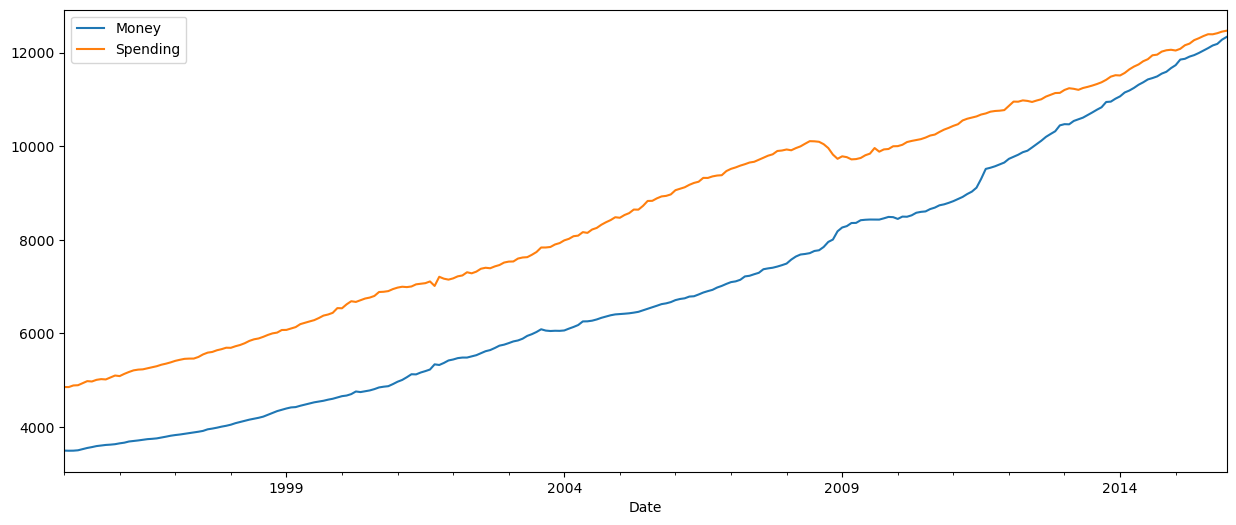

In [16]:
df.plot(kind= 'line', figsize= (15,6))
plt.show()

#### 3) ETS Decomposition:

In [17]:
decomp_money = seasonal_decompose(df['Money'], model= 'additive')

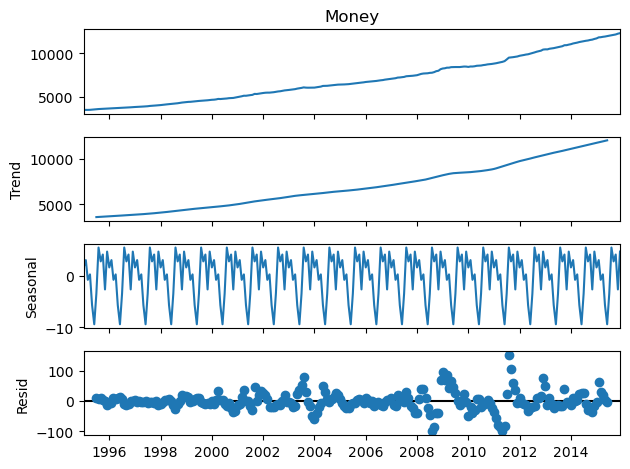

In [18]:
decomp_money.plot()
plt.show()

In [19]:
decomp_spend = seasonal_decompose(df['Spending'], model= 'additive')

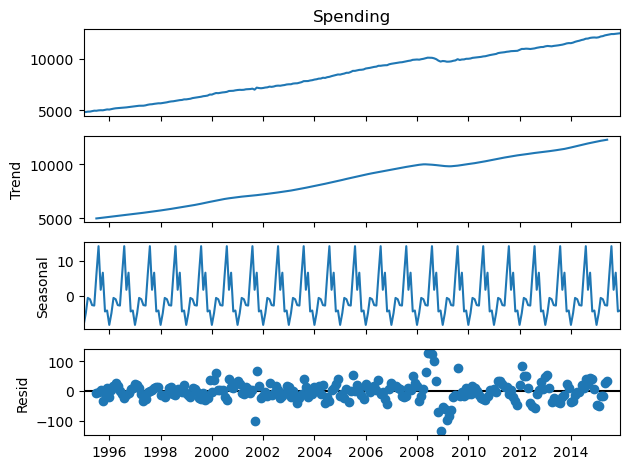

In [20]:
decomp_spend.plot()
plt.show()

#### 4) Stationarity Check:

In [21]:
from statsmodels.tsa.stattools import adfuller

def dickey_fuller_result(series):
    """
    Function To Perform Augmenter Dickey-Fuller Test and Display Results.
    """
    
    result= adfuller(series.dropna())
    
    labels = ["Test Statistics", "p-Value", "No. of Lags", "No. of Observations"]
    
    output = pd.Series(result[0:4], index= labels)
    
    for key,value in result[4].items():
        output[f"Critical Value {key}"] = value
        
    print(output)
    
    print("\n")
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis.")
        print("Reject the null hypothesis.")
        print("Data has no unit root and is stationary.")
    else:
        print("Weak evidence against the null hypothesis.")
        print("Fail to reject the null hypothesis.")
        print("Data has a unit root and is non-stationary.")

In [22]:
dickey_fuller_result(df['Money'])

Test Statistics          4.239022
p-Value                  1.000000
No. of Lags              4.000000
No. of Observations    247.000000
Critical Value 1%       -3.457105
Critical Value 5%       -2.873314
Critical Value 10%      -2.573044
dtype: float64


Weak evidence against the null hypothesis.
Fail to reject the null hypothesis.
Data has a unit root and is non-stationary.


In [23]:
dickey_fuller_result(df['Spending'])

Test Statistics          0.149796
p-Value                  0.969301
No. of Lags              3.000000
No. of Observations    248.000000
Critical Value 1%       -3.456996
Critical Value 5%       -2.873266
Critical Value 10%      -2.573019
dtype: float64


Weak evidence against the null hypothesis.
Fail to reject the null hypothesis.
Data has a unit root and is non-stationary.


`Both Time Series are Non-Stationary.`

##### Applying First Order Differencing:

In [24]:
df_diff = df.diff(periods= 1)

In [25]:
df_diff.head()

,Money,Spending
Date,,
1995-01-01,NaN,NaN
1995-02-01,-2.5,-0.4
1995-03-01,1.2,34.6
1995-04-01,8.1,4.8
1995-05-01,25.0,42.9


In [26]:
dickey_fuller_result(df_diff['Money'])

Test Statistics         -2.057404
p-Value                  0.261984
No. of Lags             15.000000
No. of Observations    235.000000
Critical Value 1%       -3.458487
Critical Value 5%       -2.873919
Critical Value 10%      -2.573367
dtype: float64


Weak evidence against the null hypothesis.
Fail to reject the null hypothesis.
Data has a unit root and is non-stationary.


In [27]:
dickey_fuller_result(df_diff['Spending'])

Test Statistics       -7.226974e+00
p-Value                2.041027e-10
No. of Lags            2.000000e+00
No. of Observations    2.480000e+02
Critical Value 1%     -3.456996e+00
Critical Value 5%     -2.873266e+00
Critical Value 10%    -2.573019e+00
dtype: float64


Strong evidence against the null hypothesis.
Reject the null hypothesis.
Data has no unit root and is stationary.


`'Money' is Non-Stationary even after first order differencing, but 'Spending' is.`

`We will apply second order differencing on both Series.`

##### Applying Second Order Differencing:

In [28]:
df_diff = df_diff.diff(periods= 1)

In [29]:
df_diff.head()

,Money,Spending
Date,,
1995-01-01,NaN,NaN
1995-02-01,NaN,NaN
1995-03-01,3.7,35.0
1995-04-01,6.9,-29.8
1995-05-01,16.9,38.1


In [30]:
dickey_fuller_result(df_diff['Money'])

Test Statistics       -7.077471e+00
p-Value                4.760675e-10
No. of Lags            1.400000e+01
No. of Observations    2.350000e+02
Critical Value 1%     -3.458487e+00
Critical Value 5%     -2.873919e+00
Critical Value 10%    -2.573367e+00
dtype: float64


Strong evidence against the null hypothesis.
Reject the null hypothesis.
Data has no unit root and is stationary.


In [32]:
dickey_fuller_result(df_diff['Spending'])

Test Statistics       -8.760145e+00
p-Value                2.687900e-14
No. of Lags            8.000000e+00
No. of Observations    2.410000e+02
Critical Value 1%     -3.457779e+00
Critical Value 5%     -2.873609e+00
Critical Value 10%    -2.573202e+00
dtype: float64


Strong evidence against the null hypothesis.
Reject the null hypothesis.
Data has no unit root and is stationary.


`Both Series are now Stationary.`

##### Dropping Missing Values:

In [33]:
df_diff.dropna(inplace= True)

In [34]:
df_diff.head()

,Money,Spending
Date,,
1995-03-01,3.7,35.0
1995-04-01,6.9,-29.8
1995-05-01,16.9,38.1
1995-06-01,-0.3,1.5
1995-07-01,-6.2,-51.7


In [35]:
df_diff.shape

(250, 2)

#### 5) Train Test Split:

In [36]:
len(df_diff)

250

In [37]:
train_data = df_diff[:-12]
test_data = df_diff[-12:]
print(train_data.shape, test_data.shape)

(238, 2) (12, 2)


#### 6) Order Selection for VAR Model:

In [40]:
model = VAR(endog= train_data)

# Automatically select the best order:
selection = model.select_order(maxlags= 10)

print(selection.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        14.81       14.84   2.703e+06       14.82
1        14.23       14.33   1.521e+06       14.27
2        14.01       14.16   1.211e+06       14.07
3        13.89      14.10*   1.081e+06       13.98
4        13.87       14.14   1.055e+06       13.98
5        13.83       14.16   1.011e+06      13.96*
6        13.83       14.22   1.016e+06       13.99
7        13.82       14.27   1.007e+06       14.00
8       13.76*       14.28  9.508e+05*       13.97
9        13.78       14.35   9.629e+05       14.01
10       13.81       14.44   9.916e+05       14.06
--------------------------------------------------


- AIC (Lag 8): Wants to minimize prediction error. It doesn't care much if the model gets complex. It says: "Use 8 lags to get the absolute best forecast accuracy."

- BIC (Lag 3): Hates complexity. It penalizes you heavily for adding extra variables. It says: "Use 3 lags. The improvement you get from 4 to 8 isn't worth the extra complexity."

- HQIC (Lag 5): Is a middle ground between the two.

We will use 5 lags.

##### 7) VAR(5) Model:

In [39]:
model = VAR(endog= train_data)
result = model.fit(maxlags= 5)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 19, Dec, 2025
Time:                     19:08:49
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    14.1131
Nobs:                     233.000    HQIC:                   13.9187
Log likelihood:          -2245.45    FPE:                    972321.
AIC:                      13.7873    Det(Omega_mle):         886628.
--------------------------------------------------------------------
Results for equation Money
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.516683         1.782238            0.290           0.772
L1.Money           -0.646232         0.068177           -9.479           0.000
L1.Spending        -0.107411         0.051388           -2.090      

##### Prediction on Test Data:

The VAR .forecast() function requires that we pass in a lag order number of previous observations as well. Unfortunately this forecast tool doesn't provide a DateTime index - we'll have to do that manually.

In [41]:
train_data.values[-5:]

array([[-31.9,  40.3],
       [  5.6, -70.7],
       [ 25.5,  52.5],
       [-21.3, -37.2],
       [ 39.5, -17.8]])

In [42]:
# Forecast:

diff_forecast = result.forecast(y= train_data.values[-5:],
                               steps= 12)

In [43]:
diff_forecast

array([[-16.99527634,  36.14982003],
       [ -3.17403756, -11.45029844],
       [ -0.377725  ,  -6.68496939],
       [ -2.60223305,   5.47945777],
       [  4.228557  ,  -2.44336505],
       [  1.55939341,   0.38763902],
       [ -0.99841027,   3.88368011],
       [  0.36451042,  -2.3561014 ],
       [ -1.21062726,  -1.22414652],
       [  0.22587712,   0.786927  ],
       [  1.33893884,   0.18097449],
       [ -0.21858453,   0.21275046]])

`We will have to Store These Forecat values in DataFrame.`

`Dataframe of Forecast values should have Same Date Index as Test Data.`

In [48]:
forecast_df = pd.DataFrame(data= diff_forecast,
                          index= list(test_data.index),
                          columns= ['Money_diff2', 'Spending_diff2'])

In [49]:
forecast_df

,Money_diff2,Spending_diff2
2015-01-01,-16.995276,36.149820
2015-02-01,-3.174038,-11.450298
2015-03-01,-0.377725,-6.684969
2015-04-01,-2.602233,5.479458
2015-05-01,4.228557,-2.443365
2015-06-01,1.559393,0.387639
2015-07-01,-0.998410,3.883680
2015-08-01,0.364510,-2.356101
2015-09-01,-1.210627,-1.224147
2015-10-01,0.225877,0.786927


##### Inverting The Transformation:

`Remember that the forecasted values represent second-order differences. To compare them to the original data we have to roll back each difference. To roll back a first-order difference we take the most recent value on the training side of the original series, and add it to a cumulative sum of forecasted values. When working with second-order differences we first must perform this operation on the most recent first-order difference.`

In [50]:
# Add the most recent first difference from the training side of the original dataset to the forecast cumulative sum
forecast_df['Money_diff1'] = (df['Money'].iloc[-12-1]-df['Money'].iloc[-12-2]) + forecast_df['Money_diff2'].cumsum()

# Now build the forecast values from the first difference set
forecast_df['Money_Forecast'] = df['Money'].iloc[-12-1] + forecast_df['Money_diff1'].cumsum()

In [51]:
forecast_df.head()

,Money_diff2,Spending_diff2,Money_diff1,Money_Forecast
2015-01-01,-16.995276,36.149820,61.604724,11731.704724
2015-02-01,-3.174038,-11.450298,58.430686,11790.135410
2015-03-01,-0.377725,-6.684969,58.052961,11848.188371
2015-04-01,-2.602233,5.479458,55.450728,11903.639099
2015-05-01,4.228557,-2.443365,59.679285,11963.318384


In [52]:
# Add the most recent first difference from the training side of the original dataset to the forecast cumulative sum
forecast_df['Spending_diff1'] = (df['Spending'].iloc[-12-1]-df['Spending'].iloc[-12-2]) + forecast_df['Spending_diff2'].cumsum()

# Now build the forecast values from the first difference set
forecast_df['Spending_Forecast'] = df['Spending'].iloc[-12-1] + forecast_df['Spending_diff1'].cumsum()

In [53]:
forecast_df.head()

,Money_diff2,Spending_diff2,Money_diff1,Money_Forecast,Spending_diff1,Spending_Forecast
2015-01-01,-16.995276,36.149820,61.604724,11731.704724,46.749820,12108.749820
2015-02-01,-3.174038,-11.450298,58.430686,11790.135410,35.299522,12144.049342
2015-03-01,-0.377725,-6.684969,58.052961,11848.188371,28.614552,12172.663894
2015-04-01,-2.602233,5.479458,55.450728,11903.639099,34.094010,12206.757904
2015-05-01,4.228557,-2.443365,59.679285,11963.318384,31.650645,12238.408549


##### Plotting Test Data and Forecast:

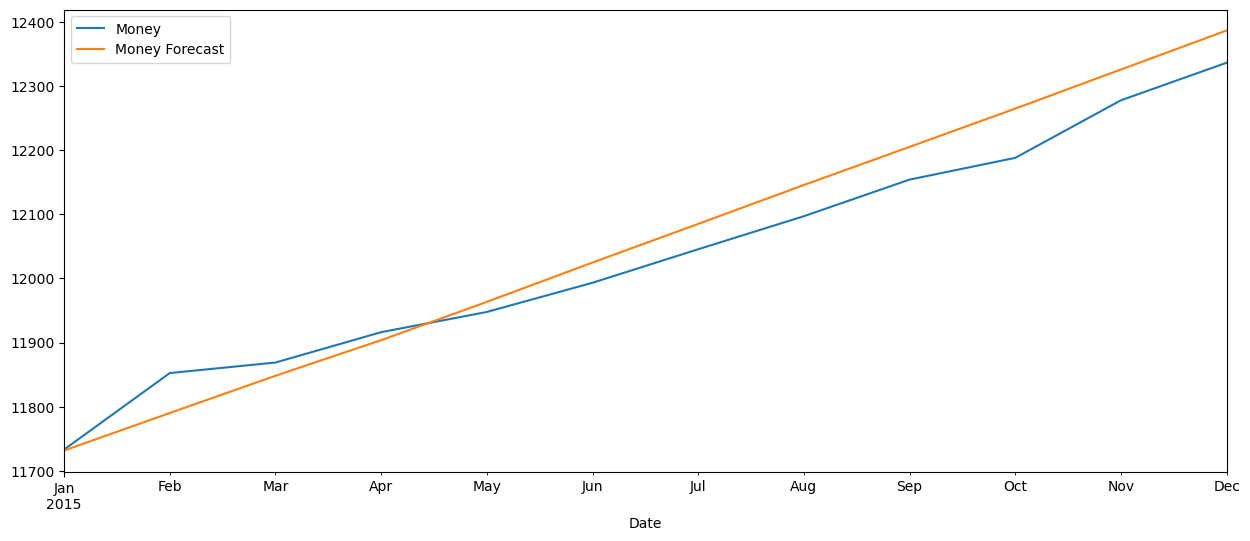

In [55]:
df['Money'][-12:].plot(figsize= (15,6), legend= True, label= 'Money')
forecast_df["Money_Forecast"].plot(label= "Money Forecast", legend= True)
plt.show()

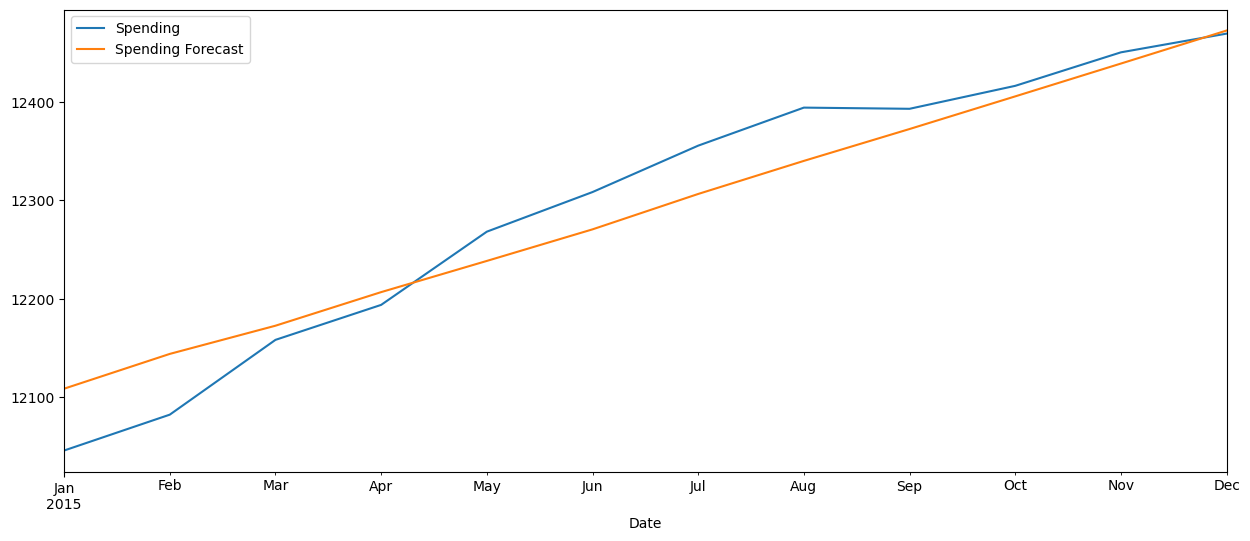

In [56]:
df['Spending'][-12:].plot(figsize= (15,6), legend= True, label= 'Spending')
forecast_df['Spending_Forecast'].plot(label= 'Spending Forecast', legend= True)
plt.show()

##### Model Evaluation:

In [58]:
print(np.sqrt(mean_squared_error(df['Money'][-12:], forecast_df['Money_Forecast'])))
print(np.sqrt(mean_squared_error(df['Spending'][-12:], forecast_df['Spending_Forecast'])))

43.710496535589265
37.00117516940808


In [59]:
print(df['Money'].mean())
print(df['Spending'].mean())

6978.15119047619
8562.311904761904
